<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/S08_1_Proyecto_Ciencia_Datos_Fuga_Clientes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Definición del proyecto

**Fuga de Clientes de Telecomunicaciones**<br>
Contexto: Actualmente se vienen manifestando fuga de clientes, el cual se encuentra por encima del mercado (15%), por lo que es necesario conocer el comportamiento que los motivo a retirarse de la compañía a través de la aplicación de análisis de datos y predecir el comportamiento para retener a los clientes a través de algoritmos de Machine Learning.


## 0. Objetivo
Desarrollar programas específicos de retención de clientes

###Notas Adicionales
El conjunto de datos incluye información sobre:
<ol><li>
Clientes que se fueron en el último mes: la columna se llama Churn<li>
Servicios a los que cada cliente se ha suscrito: teléfono, líneas múltiples, Internet, seguridad en línea, respaldo en línea, protección de dispositivos, soporte técnico y transmisión de TV y películas. <li>Información de la cuenta del cliente: cuánto tiempo ha sido cliente, contrato, método de pago, facturación electrónica, cargos mensuales y cargos totales<li>
Información demográfica sobre los clientes: género, rango de edad y si tienen parejas y dependientes</ol>

# Desarrollo del proyecto

## 1. Imports Básicos

In [1]:
#Import basicos
import pandas as pd #Manipulacion de datos
import numpy as np #Procesamiento de datos
import matplotlib #Visualizacion de datos
matplotlib.use('Agg')

import matplotlib.pyplot as plt #Visualizacion de datos
import seaborn as sns #Visualizacion de datos

sns.set(style='darkgrid') #Comando para el estilo de los gráficos
%matplotlib inline

## 2. Carga inicial de datos






In [5]:
#Carga de Dataset
# fuga = pd.read_csv('telecom_customer_churn.csv',sep=";")
fuga = pd.read_csv('https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/Sesion_8_telecom_customer_churn.csv', sep = ';')

## 3. Diccionario de datos

<table>
  <tr>
    <th>Nombre de Campo</th>
    <th>Descripción</th>
    <th>Tipo de Variable</th>
    <th>Tipo de Dato</th>
  </tr>
  <tr>
    <td>Churn</td>
    <td>Si el cliente abandonó o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí o No)</td>
  </tr>
  <tr>
    <td>CustomerID</td>
    <td>Identificación del cliente</td>
    <td>string</td>
    <td></td>
  </tr>
  <tr>
    <td>Gender</td>
    <td>Si el cliente es hombre o mujer</td>
    <td>Categorico Nominal</td>
    <td>(Male,Female)</td>
  </tr>
  <tr>
    <td>SeniorCitizen</td>
    <td>Si el cliente es adulto mayor o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(0,1)</td>
  </tr>
  <tr>
    <td>Partner</td>
    <td>Si el cliente tiene pareja o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>Dependets</td>
    <td>Si el cliente tiene dependientes o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>Tenure</td>
    <td>Número de meses que el cliente ha permanecido en la empresa</td>
    <td>Discreto</td>
    <td></td>
  </tr>
  <tr>
    <td>PhoneService</td>
    <td>Si el cliente tiene servicio telefónico o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>MultipleLines</td>
    <td>Si el cliente tiene varias líneas o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio telefónico)</td>
  </tr>
  <tr>
    <td>InternetService</td>
    <td>Proveedor de servicios de Internet del cliente</td>
    <td>Categorico nominal</td>
    <td>(DSL, Fibra óptica, No)</td>
  </tr>
  <tr>
    <td>OnlineSecurity</td>
    <td>Si el cliente tiene seguridad en línea o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No, Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>OnlineBackup</td>
    <td>Si el cliente tiene respaldo en línea o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No, Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>DeviceProtection</td>
    <td>Si el cliente tiene protección de dispositivo o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>TechSupport</td>
    <td>Si el cliente cuenta con soporte técnico o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>StreamingTV</td>
    <td>Si el cliente tiene transmisión de TV o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>StreamingMovies</td>
    <td>Si el cliente tiene películas en streaming o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>Contract</td>
    <td>El plazo del contrato del cliente</td>
    <td>Categorico nominal</td>
    <td>(Mes a mes, Un año, Dos años)</td>
  </tr>
  <tr>
    <td>Paperlessbilling</td>
    <td>Si el cliente tiene facturación electrónica o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>PaymentMethod</td>
    <td>El método de pago del cliente</td>
    <td>Categorico nominal</td>
    <td>(Cheque electrónico, Cheque enviado por correo, Transferencia bancaria)</td>
  </tr>
  <tr>
    <td>MonthlyChargues</td>
    <td>El monto cobrado al cliente mensualmente</td>
    <td>Discreto</td>
    <td></td>
  </tr>
  <tr>
    <td>TotalChargues</td>
    <td>El importe total cobrado al cliente</td>
    <td>Discreto</td>
    <td></td>
  </tr>
</table>


##4. Analisis inicial de los datos

In [7]:
#Dimensión del Dataset
fuga.shape

(7043, 21)

**Hallazgo:**

La base de datos de Fuga de Clientes de Telecomunicaciones cuenta con un total de 21 columnas y 7043 registros.

In [9]:
#Columnas disponibles
fuga.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'customerID'],
      dtype='object')

In [10]:
#Tipos de datos disponibles
fuga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
fuga.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


**Hallazgo:**

*   De las 21 variables, 17 son de texto o categóricas (object) y 4 son numéricas (2 enteras y 2 continuas)
*   De las 21 variables, 1 cuenta con valores nulos (11 de 7,043 registros)



In [12]:
#Visualizar los primeros 5 registros
fuga.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,7590-VHVEG
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5575-GNVDE
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3668-QPYBK
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7795-CFOCW
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,9237-HQITU


In [ ]:
#Visualizar los últimos 5 registros
fuga.tail()

Calcular la cantidad de clientes que abandonaron (Churn)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn
No     0.73463
Yes    0.26537
Name: count, dtype: float64


<Axes: xlabel='Churn'>

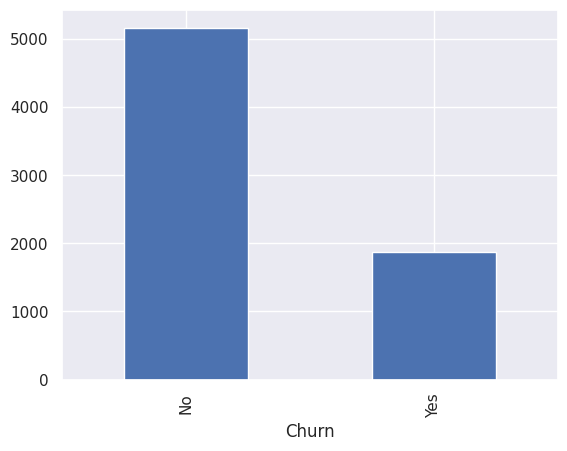

In [19]:
# Calcular la cantidad de clientes que abandonaron (churn) y los que no
churn_count = fuga["Churn"].value_counts()
total = len(fuga["Churn"])
print(churn_count)

print('\n')
print(churn_count/total)

# Visualizar la cantidad de clientes que abandonaron (churn) y los que no
fuga["Churn"].value_counts().plot(kind="bar")

In [ ]:
1869/7043

**Hallazgo:**

El 26.5% de clientes ha abandonado la companía de telecomunicaciones, por lo que se encuentra por encima del valor referencial del mercado (15%). Se sugiere que el tipo de dato de la variable target se encuentre en numérico.

In [20]:
#Cambiar el tipo de dato de la variable Target
fuga["Churn"] = fuga["Churn"].replace(['No'],'0')
fuga["Churn"] = fuga["Churn"].replace(['Yes'],'1')
fuga["Churn"] = fuga["Churn"].astype('int')

In [21]:
fuga.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,7590-VHVEG
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,5575-GNVDE
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3668-QPYBK
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,7795-CFOCW
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,9237-HQITU


## 5. Analisis estadístico de los datos

### *5.1* Análisis de variables cuantitativas

#### *5.1.1* Análisis univariado

El objeto del análisis univariado es poder describir a la variable de manera interna, es decir conocer su comportamiento y distribución.

In [22]:
#Resumen estadístico de las variables numéricas
fuga.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370
std,0.368612,24.559481,30.090047,2266.771362,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


**Hallazgos:**

* La variable "Churn" y "SeniorCitizen" no tienen interpretación estadística ya que son variables booleanas.
* La variable "Tenure" se determina que el promedio es de 32.37 meses en el que un cliente permaneció en la empresa además es un valor cercano a la mediana, que es 29 meses y mayor que la desviación estándar por lo que existe evidencia para afirmar que no presentan valores atípicos extremas.
* La variable "MonthlyCharges" se determina que el promedio es de 64.75 unidades en el que un cliente paga mensualmente además es un valor cercano a la mediana, que es 70 unidades y mayor que la desviación estándar por lo que existe evidencia para afirmar que no presentan valores atípicos extremas.
* La variable "TotalChargues" se determina que el promedio es de 2283 unidades que es el consumo total promedio del cliente, además observamos que se encuentra alejado de la mediana, el cual es 1397 unidades y más bien la desviación se encuentra cercano al promedio por lo que existe presunta evidencia de que presente valores atípicos extremos.

Realizaremos el Diagrama de Caja para obtener la distribución de cada variable:

Para el cálculo del valor máximo y minimo se realiza lo siguiente:

Valor máx: Q3 + 1.5*RI

Valor min: Q1 - 1.5*RI

donde RI es el rango intercuartilico que es la diferencia de Q3 - Q1

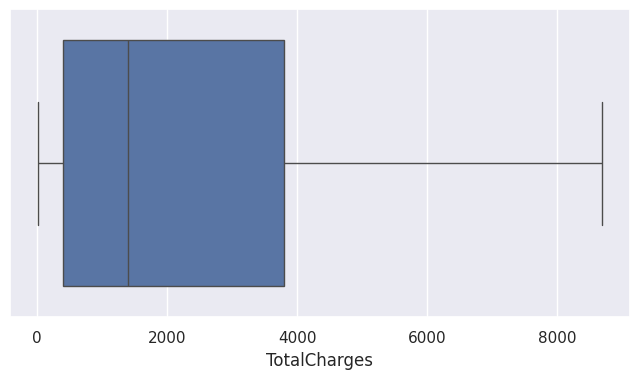

In [23]:
#Diagrama de caja univariado
plt.figure(figsize=(8,4))
sns.boxplot(data=fuga, x = "TotalCharges")
plt.show()

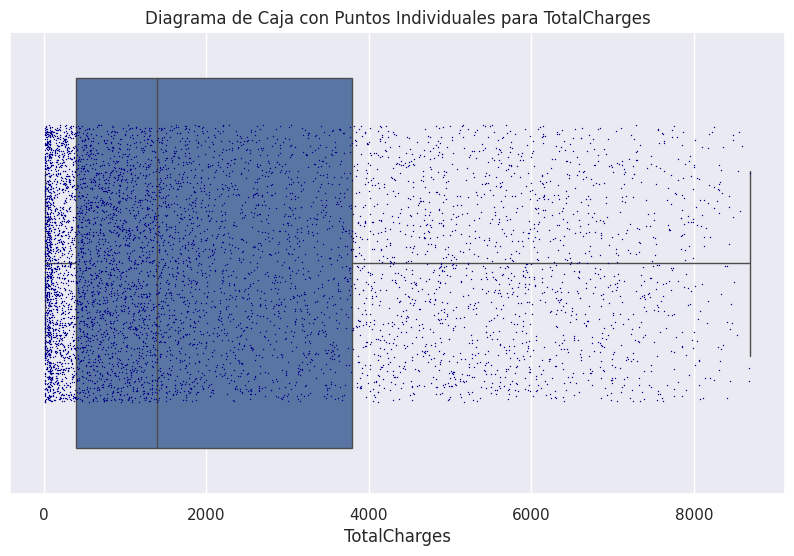

In [29]:
# ALEXIS: Añadir una visualización de los distintos data points

plt.figure(figsize=(10, 6))
sns.boxplot(data=fuga, x="TotalCharges")
sns.stripplot(data=fuga, x="TotalCharges", color='darkblue', size=1, jitter=0.3)
plt.title('Diagrama de Caja con Puntos Individuales para TotalCharges')
plt.show()

**Hallazgo:**

No observamos valores fuera de los extremos, por lo tanto podemos afirmar que no existen valores atípicos.

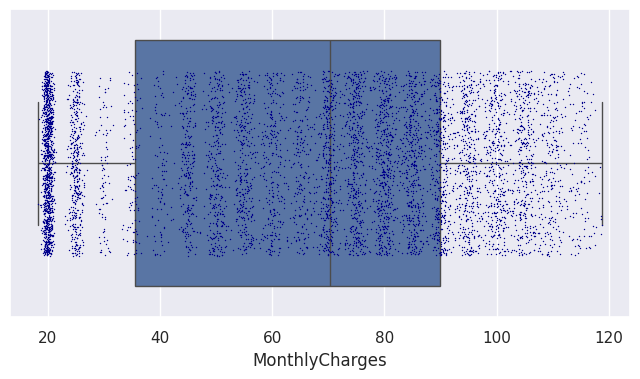

In [31]:
#Diagrama de caja univariado
plt.figure(figsize=(8,4))
sns.boxplot(data=fuga, x = "MonthlyCharges")
sns.stripplot(data=fuga, x="MonthlyCharges", color='darkblue', size=1, jitter=0.3)
plt.show()

**Hallazgo:**

Graficando el diagrama de caja, observamos que no existen valores atípicos en las variables numéricas

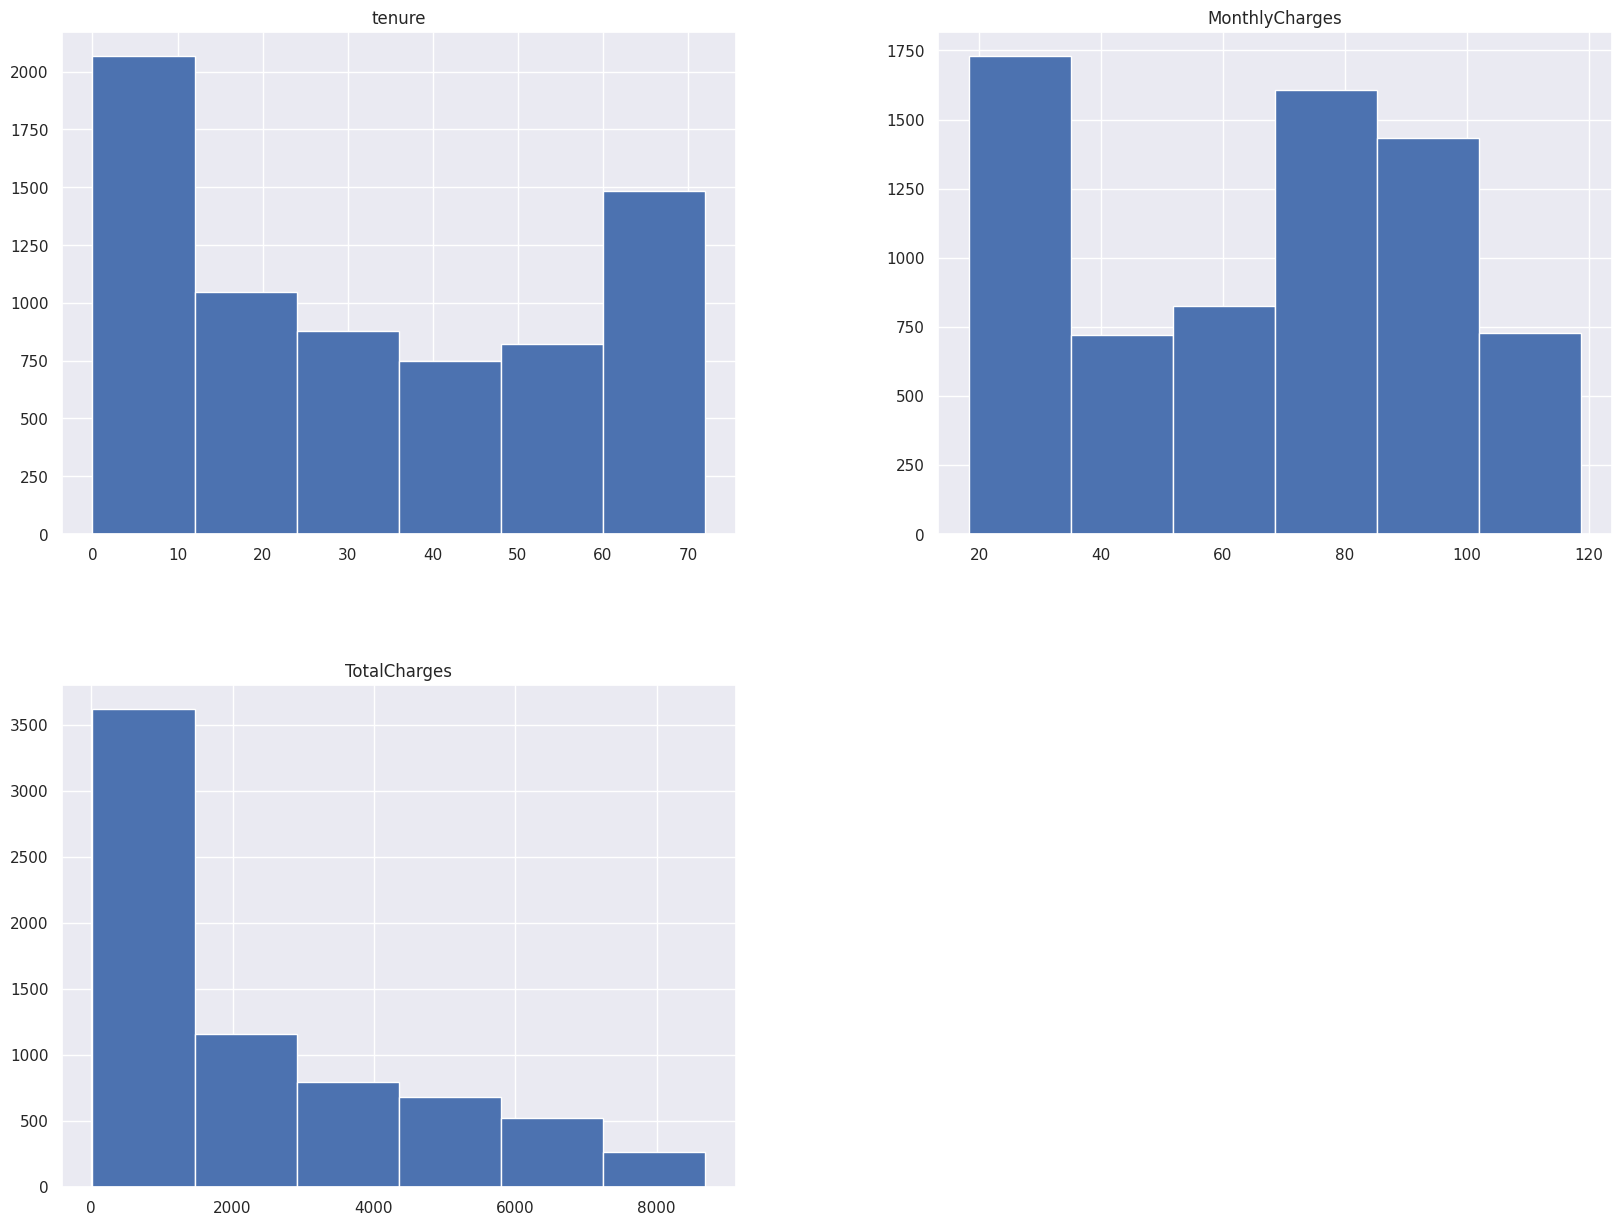

In [32]:
#Visualización univariada de las variables
columns_to_include = ['tenure', 'MonthlyCharges', 'TotalCharges']
fuga[columns_to_include].hist(bins = 6, figsize=(20,15))
plt.show()

#### *5.1.2* Análisis bivariado

<Axes: >

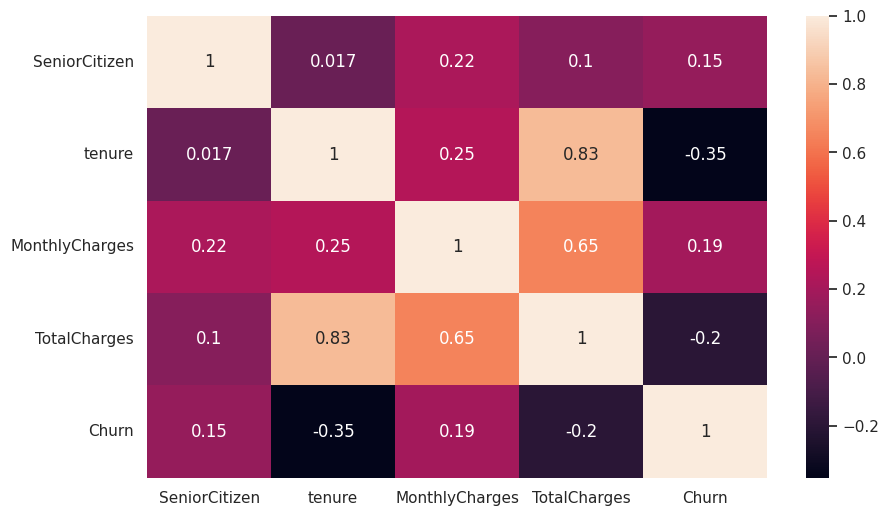

In [33]:
#Análisis Bivariado: Correlación
corr = fuga[['SeniorCitizen','tenure', 'MonthlyCharges', 'TotalCharges','Churn']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)

Interpretación Correlación:

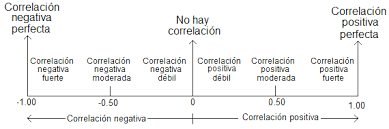

**Hallazgo:**

Observamos que la variable que tiene mejor relación con el fuga, es tenure (tiempo de permanencia), la cual es negativa, lo que nos dice que mientras el tiempo de permanencia incrementa, la fuga disminuye. Seguida está Total Chargues, Monthly Chargues y Tenur


### *5.2* Análisis de variables cualitativas

In [34]:
#Creamos un dataset donde filtremos a las variables categóricas
categorical_attributes = fuga.select_dtypes(include=['object'])

In [35]:
categorical_attributes.dtypes

,0
gender,object
Partner,object
Dependents,object
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object
DeviceProtection,object
TechSupport,object


<table>
  <tr>
    <th>Nombre de Campo</th>
    <th>Descripción</th>
    <th>Tipo de Variable</th>
    <th>Tipo de Dato</th>
  </tr>
  <tr>
    <td>Churn</td>
    <td>Si el cliente abandonó o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí o No)</td>
  </tr>
  <tr>
    <td>CustomerID</td>
    <td>Identificación del cliente</td>
    <td>string</td>
    <td></td>
  </tr>
  <tr>
    <td>Gender</td>
    <td>Si el cliente es hombre o mujer</td>
    <td>Categorico Nominal</td>
    <td>(Male,Female)</td>
  </tr>
  <tr>
    <td>SeniorCitizen</td>
    <td>Si el cliente es adulto mayor o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(0,1)</td>
  </tr>
  <tr>
    <td>Partner</td>
    <td>Si el cliente tiene pareja o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>Dependets</td>
    <td>Si el cliente tiene dependientes o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>Tenure</td>
    <td>Número de meses que el cliente ha permanecido en la empresa</td>
    <td>Discreto</td>
    <td></td>
  </tr>
  <tr>
    <td>PhoneService</td>
    <td>Si el cliente tiene servicio telefónico o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>MultipleLines</td>
    <td>Si el cliente tiene varias líneas o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio telefónico)</td>
  </tr>
  <tr>
    <td>InternetService</td>
    <td>Proveedor de servicios de Internet del cliente</td>
    <td>Categorico nominal</td>
    <td>(DSL, Fibra óptica, No)</td>
  </tr>
  <tr>
    <td>OnlineSecurity</td>
    <td>Si el cliente tiene seguridad en línea o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No, Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>OnlineBackup</td>
    <td>Si el cliente tiene respaldo en línea o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No, Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>DeviceProtection</td>
    <td>Si el cliente tiene protección de dispositivo o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>TechSupport</td>
    <td>Si el cliente cuenta con soporte técnico o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>StreamingTV</td>
    <td>Si el cliente tiene transmisión de TV o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>StreamingMovies</td>
    <td>Si el cliente tiene películas en streaming o no</td>
    <td>Categorico nominal</td>
    <td>(Sí, No,Sin servicio de Internet)</td>
  </tr>
  <tr>
    <td>Contract</td>
    <td>El plazo del contrato del cliente</td>
    <td>Categorico nominal</td>
    <td>(Mes a mes, Un año, Dos años)</td>
  </tr>
  <tr>
    <td>Paperlessbilling</td>
    <td>Si el cliente tiene facturación electrónica o no</td>
    <td>Categorico nominal, Booleano</td>
    <td>(Sí, No)</td>
  </tr>
  <tr>
    <td>PaymentMethod</td>
    <td>El método de pago del cliente</td>
    <td>Categorico nominal</td>
    <td>(Cheque electrónico, Cheque enviado por correo, Transferencia bancaria)</td>
  </tr>
  <tr>
    <td>MonthlyChargues</td>
    <td>El monto cobrado al cliente mensualmente</td>
    <td>Discreto</td>
    <td></td>
  </tr>
  <tr>
    <td>TotalChargues</td>
    <td>El importe total cobrado al cliente</td>
    <td>Discreto</td>
    <td></td>
  </tr>
</table>

Se analiza cada variable categórica relacionadola con el Target, donde el objetivo es validar si el % de Churn cambia de acuerdo a la categoría de cada variable.

In [36]:
fuga['Churn'].describe()

,Churn
count,7043.000000
mean,0.265370
std,0.441561
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [37]:
#Analizamos la variable Gender
fuga[['gender', 'Churn']].groupby(['gender'], as_index=False).agg(['count','sum','mean'])

gender Churn               
          count  sum      mean
0  Female  3488  939  0.269209
1    Male  3555  930  0.261603

**Hallazgo:**

La variable "Gender" no discrimina el comportamiento del Target debido a que la proporción de fuga en cada categoría es similar a la proporción general.



In [38]:
#Analizamos la variable Partner
fuga[['Partner', 'Churn']].groupby(['Partner'], as_index=False).agg(['count','sum','mean'])

Partner Churn                
          count   sum      mean
0      No  3641  1200  0.329580
1     Yes  3402   669  0.196649

**Hallazgo:**

La variable "Partner" si discrimina el comportamiento del Target, porque observamos un cambio de comportamiento en la proporción de Fuga de cada categoría respecto a la proporción general.

In [41]:
fuga[['Dependents', 'Churn']].groupby(['Dependents'], as_index=True).agg(['count','sum','mean'])

Churn                
           count   sum      mean
Dependents                      
No          4933  1543  0.312791
Yes         2110   326  0.154502

In [43]:
for v in categorical_attributes:
  display(fuga[[v, 'Churn']].groupby([v], as_index=True).agg(['count','sum','mean']))

Churn               
       count  sum      mean
gender                     
Female  3488  939  0.269209
Male    3555  930  0.261603

Churn                
        count   sum      mean
Partner                      
No       3641  1200  0.329580
Yes      3402   669  0.196649

Churn                
           count   sum      mean
Dependents                      
No          4933  1543  0.312791
Yes         2110   326  0.154502

Churn                
             count   sum      mean
PhoneService                      
No             682   170  0.249267
Yes           6361  1699  0.267096

Churn               
                 count  sum      mean
MultipleLines                        
No                3390  849  0.250442
No phone service   682  170  0.249267
Yes               2971  850  0.286099

...

Churn               
                    count  sum      mean
StreamingMovies                         
No                   2785  938  0.336804
No internet service  1526  113  0.074050
Yes                  2732  818  0.299414

Churn                
               count   sum      mean
Contract                            
Month-to-month  3875  1655  0.427097
One year        1473   166  0.112695
Two year        1695    48  0.028319

Churn                
                 count   sum      mean
PaperlessBilling                      
No                2872   469  0.163301
Yes               4171  1400  0.335651

Churn                
                          count   sum      mean
PaymentMethod                                  
Bank transfer (automatic)  1544   258  0.167098
Credit card (automatic)    1522   232  0.152431
Electronic check           2365  1071  0.452854
Mailed check               1612   308  0.191067

Churn         
           count sum mean
customerID               
0002-ORFBO     1   0  0.0
0003-MKNFE     1   0  0.0
0004-TLHLJ     1   1  1.0
0011-IGKFF     1   1  1.0
0013-EXCHZ     1   1  1.0
...          ...  ..  ...
9987-LUTYD     1   0  0.0
9992-RRAMN     1   1  1.0
9992-UJOEL     1   0  0.0
9993-LHIEB     1   0  0.0
9995-HOTOH     1   0  0.0

[7043 rows x 3 columns]

La variable "Dependents" si discrimina el comportamiento del Target.

In [ ]:
fuga[['PhoneService', 'Churn']].groupby(['PhoneService'], as_index=False).agg(['count','sum','mean'])

La variable "Phone Service" no discrimina el comportamiento del Target.

In [ ]:
fuga[['MultipleLines', 'Churn']].groupby(['MultipleLines'], as_index=False).agg(['count','sum','mean'])

La variable "MultipleLines" no discrimina el comportamiento del Target.

In [ ]:
fuga[['InternetService', 'Churn']].groupby(['InternetService'], as_index=False).agg(['count','sum','mean'])

La variable "InternetService" si discrimina el comportamiento del Target.

In [ ]:
fuga[['OnlineSecurity', 'Churn']].groupby(['OnlineSecurity'], as_index=False).agg(['count','sum','mean'])

La variable "OnlineSecurity" si discrimina el comportamiento del Target.

In [ ]:
fuga[['OnlineBackup', 'Churn']].groupby(['OnlineBackup'], as_index=False).agg(['count','sum','mean'])

La variable "OnlineBackup" si discrimina el comportamiento del Target.

In [ ]:
fuga[['DeviceProtection', 'Churn']].groupby(['DeviceProtection'], as_index=False).agg(['count','sum','mean'])

La variable "DeviceProtection" si discrimina el comportamiento del Target.

In [ ]:
fuga[['TechSupport', 'Churn']].groupby(['TechSupport'], as_index=False).agg(['count','sum','mean'])

La variable "TechSupport" si discrimina el comportamiento del Target.

In [ ]:
fuga[['StreamingTV', 'Churn']].groupby(['StreamingTV'], as_index=False).agg(['count','sum','mean'])

La variable "StreamingTV" no discrimina el comportamiento del Target.

In [ ]:
fuga[['StreamingMovies', 'Churn']].groupby(['StreamingMovies'], as_index=False).agg(['count','sum','mean'])

La variable "StreamingMovies" no discrimina el comportamiento del Target.

In [ ]:
fuga[['Contract', 'Churn']].groupby(['Contract'], as_index=False).agg(['count','sum','mean'])

La variable "Contract" si discrimina el comportamiento del Target.

In [ ]:
fuga[['PaperlessBilling', 'Churn']].groupby(['PaperlessBilling'], as_index=False).agg(['count','sum','mean'])

La variable "PaperlessBilling" si discrimina el comportamiento del Target.

In [44]:
fuga[['PaymentMethod', 'Churn']].groupby(['PaymentMethod'], as_index=False).agg(['count','sum','mean'])

PaymentMethod Churn                
                             count   sum      mean
0  Bank transfer (automatic)  1544   258  0.167098
1    Credit card (automatic)  1522   232  0.152431
2           Electronic check  2365  1071  0.452854
3               Mailed check  1612   308  0.191067

La variable "PaymentMethod" si discrimina el comportamiento del Target.

Del total de variables revisadas, nos quedamos con 11 variables:
*   PaymentMethod
*   PaperlessBilling
*   Contract
*   TechSupport
*   DeviceProtection
*   OnlineBackup
*   OnlineSecurity
*   InternetService
*   Dependents
*   Partners
*   Tenure